In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb
import numpy as np
import matplotlib.pyplot as plt
import time
import seaborn as sns
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import precision_score, recall_score, f1_score
import random
import numpy as np
import tensorflow as tf

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)

In [ ]:
VOCAB_SIZE = 5000
MAX_LEN = 200
BATCH_SIZE = 64
EPOCHS_TEACHER = 5
EPOCHS_STUDENT = 5

**create_teacher_model** defines a bidirectional LSTM model as the teacher using embedding layers and two BiLSTM layers followed by a dense output. This model serves as the source of knowledge for distillation.

**create_student_model** defines a smaller LSTM model as the student, with fewer parameters (embedding dimension 32, single LSTM). This model is intended to learn from the teacher either directly or through distillation.

In [ ]:
def create_teacher_model():
    inputs = layers.Input(shape=(MAX_LEN,))
    x = layers.Embedding(VOCAB_SIZE, 128)(inputs)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True), name="bilstm1")(x)
    x = layers.Bidirectional(layers.LSTM(64), name="bilstm2")(x)
    outputs = layers.Dense(2)(x)

    return Model(inputs, outputs)


def create_student_model():
    inputs = layers.Input(shape=(MAX_LEN,))
    x = layers.Embedding(VOCAB_SIZE, 32)(inputs)
    x = layers.LSTM(32, name="lstm")(x)
    outputs = layers.Dense(2)(x)

    return Model(inputs, outputs)


Class **Distiller** implements a knowledge distillation wrapper combining the student's classification loss with a KL-divergence term between teacher and student soft logits. Training and test steps were overridden to compute both losses and update metrics.

In [ ]:
class Distiller(tf.keras.Model):
    def __init__(self, student, temperature=4, alpha=0.5):
        super().__init__()
        self.student = student
        self.temperature = temperature
        self.alpha = alpha
        self.student_loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)
        self.distill_loss_fn = tf.keras.losses.KLDivergence()

    def compile(self, optimizer, metrics):
        super().compile(optimizer=optimizer, metrics=metrics)

    def train_step(self, data):
        x, y, teacher_logits = data
        with tf.GradientTape() as tape:
            student_logits = self.student(x, training=True)
            student_loss = self.student_loss_fn(y, student_logits)
            teacher_soft = tf.nn.softmax(teacher_logits / self.temperature)
            student_soft = tf.nn.softmax(student_logits / self.temperature)
            distill_loss = self.distill_loss_fn(teacher_soft, student_soft)
            loss = self.alpha * student_loss + (1 - self.alpha) * (self.temperature ** 2) * distill_loss

        grads = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.student.trainable_variables))

        for metric in self.metrics:
            metric.update_state(y, tf.nn.softmax(student_logits))

        results = {metric.name: metric.result() for metric in self.metrics}
        results["loss"] = loss

        return results

    def test_step(self, data):
        x, y, teacher_logits = data
        logits = self.student(x, training=False)

        for metric in self.metrics:
            metric.update_state(y, tf.nn.softmax(logits))

        return {metric.name: metric.result() for metric in self.metrics}



Class **FeatureDistiller** implements feature-based KD by matching intermediate hidden states (teacher BiLSTM vs student LSTM) using a mean-squared error loss. The student’s classification loss was combined with the feature loss, allowing transfer of internal representations.

In [ ]:
class FeatureDistiller(tf.keras.Model):
    def __init__(self, student, teacher, alpha=0.5):
        super().__init__()
        self.student = student
        self.teacher = teacher
        self.alpha = alpha
        self.student_loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)
        self.feature_loss_fn = tf.keras.losses.MeanSquaredError()
        student_units = self.student.get_layer("lstm").units
        self.feature_projector = layers.Dense(student_units)
        self.teacher_feature_model = Model(teacher.input, teacher.get_layer("bilstm2").output)
        self.student_feature_model = Model(student.input, student.get_layer("lstm").output)

    def compile(self, optimizer, metrics):
        super().compile(optimizer=optimizer, metrics=metrics)

    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            teacher_features = self.teacher_feature_model(x, training=False)
            student_features = self.student_feature_model(x, training=True)
            teacher_features_proj = self.feature_projector(teacher_features)
            student_logits = self.student(x, training=True)
            student_loss = self.student_loss_fn(y, student_logits)
            feature_loss = self.feature_loss_fn(teacher_features_proj, student_features)
            loss = self.alpha * student_loss + (1 - self.alpha) * feature_loss

        train_vars = self.student.trainable_variables + self.feature_projector.trainable_variables
        grads = tape.gradient(loss, train_vars)
        self.optimizer.apply_gradients(zip(grads, train_vars))

        for metric in self.metrics:
            metric.update_state(y, tf.nn.softmax(student_logits))

        results = {metric.name: metric.result() for metric in self.metrics}
        results["loss"] = loss

        return results

    def test_step(self, data):
        x, y = data
        logits = self.student(x, training=False)

        for metric in self.metrics:
            metric.update_state(y, tf.nn.softmax(logits))

        return {metric.name: metric.result() for metric in self.metrics}


Class **AttentionDistiller** implements attention-based KD by aligning the “attention” or importance patterns of teacher and student hidden states. A combined loss including classification, logit distillation, and attention alignment was used.

In [ ]:
class AttentionDistiller(tf.keras.Model):
    def __init__(self, student, teacher, temperature=4, alpha=0.5):
        super().__init__()
        self.student = student
        self.teacher = teacher
        self.temperature = temperature
        self.alpha = alpha
        self.student_loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)
        self.distill_loss_fn = tf.keras.losses.KLDivergence()
        self.attn_loss_fn = tf.keras.losses.MeanSquaredError()
        self.teacher_feature_model = Model(teacher.input, teacher.get_layer("bilstm2").output)
        self.student_feature_model = Model(student.input, student.get_layer("lstm").output)

    def train_step(self, data):
        x, y, teacher_logits = data
        with tf.GradientTape() as tape:
            student_logits = self.student(x, training=True)
            student_loss = self.student_loss_fn(y, student_logits)
            teacher_features = self.teacher_feature_model(x, training=False)
            student_features = self.student_feature_model(x, training=True)
            attn_loss = self.attn_loss_fn(tf.reduce_mean(tf.abs(teacher_features), axis=-1), tf.reduce_mean(tf.abs(student_features), axis=-1))
            teacher_soft = tf.nn.softmax(teacher_logits / self.temperature)
            student_soft = tf.nn.softmax(student_logits / self.temperature)
            distill_loss = self.distill_loss_fn(teacher_soft, student_soft)
            loss = self.alpha * student_loss + (1 - self.alpha) * (self.temperature ** 2) * distill_loss + 0.5 * attn_loss

        grads = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.student.trainable_variables))

        for metric in self.metrics:
            metric.update_state(y, tf.nn.softmax(student_logits))

        results = {metric.name: metric.result() for metric in self.metrics}
        results["loss"] = loss
        return results

    def test_step(self, data):
        if len(data) == 3:
            x, y, _ = data
        else:
            x, y = data

        logits = self.student(x, training=False)
        for metric in self.metrics:
            metric.update_state(y, tf.nn.softmax(logits))
        return {metric.name: metric.result() for metric in self.metrics}


Loading and padding to fixed sequence length IMDB sentiment dataset. Labels were one-hot encoded and subsets of training and test data were used to reduce computation for rapid prototyping.

In [ ]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

x_train = pad_sequences(x_train, maxlen=MAX_LEN, padding='post')
x_test = pad_sequences(x_test, maxlen=MAX_LEN, padding='post')
y_train_cat = tf.keras.utils.to_categorical(y_train, 2)
y_test_cat = tf.keras.utils.to_categorical(y_test, 2)

x_train_sub = x_train[:10000]
y_train_sub = y_train_cat[:10000]
x_test_sub = x_test[:2000]
y_test_sub = y_test_cat[:2000]

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Compiling and training the teacher BiLSTM model using categorical cross-entropy with performance tracking on the validation subset. Predictions (logits) were stored for student distillation.

In [ ]:
teacher = create_teacher_model()

teacher.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.CategoricalAccuracy(name="accuracy")]
)

teacher.fit(
    x_train_sub,
    y_train_sub,
    validation_data=(x_test_sub, y_test_sub),
    epochs=EPOCHS_TEACHER,
    batch_size=BATCH_SIZE
)

teacher_train_logits = teacher.predict(x_train_sub, batch_size=BATCH_SIZE)
teacher_test_logits = teacher.predict(x_test_sub, batch_size=BATCH_SIZE)


Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.6019 - loss: 0.6648 - val_accuracy: 0.7480 - val_loss: 0.5439
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.7757 - loss: 0.4715 - val_accuracy: 0.8015 - val_loss: 0.4312
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.8797 - loss: 0.3025 - val_accuracy: 0.8315 - val_loss: 0.4041
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9074 - loss: 0.2448 - val_accuracy: 0.8305 - val_loss: 0.4380
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9328 - loss: 0.1822 - val_accuracy: 0.8400 - val_loss: 0.4422
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


Training a standard student model without distillation to serve as a baseline for comparison.

In [ ]:
student_baseline = create_student_model()

student_baseline.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.CategoricalAccuracy(name="accuracy")]
)

student_baseline.fit(
    x_train_sub,
    y_train_sub,
    validation_data=(x_test_sub, y_test_sub),
    epochs=EPOCHS_STUDENT,
    batch_size=BATCH_SIZE
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5466 - loss: 0.6822 - val_accuracy: 0.5925 - val_loss: 0.8514
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6064 - loss: 0.6529 - val_accuracy: 0.5985 - val_loss: 0.6127
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6646 - loss: 0.6352 - val_accuracy: 0.5490 - val_loss: 0.6755
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6101 - loss: 0.6313 - val_accuracy: 0.6530 - val_loss: 0.6287
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6477 - loss: 0.6063 - val_accuracy: 0.5640 - val_loss: 0.6782


1. creating all student models and their corresponding distiller wrappersincluding logit-based, feature-based, and attention-based KD variants;
2. preparing datasets with teacher logits (for logit/attention KD) or without (for feature KD). Data was batched and shuffled for efficient training;
3. compiling all distiller models with the Adam optimizer and categorical accuracy as the metric;
4. training each distiller model for a fixed number of epochs on the appropriate dataset. Feature KD used only input data, while logit and attention KD used teacher predictions.

In [ ]:
student_kd = create_student_model()
student_feature = create_student_model()
student_attention = create_student_model()

distiller_kd = Distiller(student_kd)
distiller_feature = FeatureDistiller(student_feature, teacher)
distiller_attention = AttentionDistiller(student_attention, teacher)

students = [student_kd, student_feature, student_attention]
distillers = [ distiller_kd, distiller_feature, distiller_attention]
names = ["Logit-based KD", "Feature KD", "Attention KD"]

train_dataset = tf.data.Dataset.from_tensor_slices((x_train_sub, y_train_sub, teacher_train_logits)).shuffle(1000).batch(BATCH_SIZE)
test_dataset = tf.data.Dataset.from_tensor_slices((x_test_sub, y_test_sub, teacher_test_logits)).batch(BATCH_SIZE)

for d in distillers:
    d.compile(
        optimizer=tf.keras.optimizers.Adam(),
        metrics=[tf.keras.metrics.CategoricalAccuracy(name="accuracy")]
    )

for name, d in zip(names, distillers):
    print(f"\nTraining {name}...")
    if isinstance(d, FeatureDistiller):
        dataset = tf.data.Dataset.from_tensor_slices((x_train_sub, y_train_sub)).shuffle(1000).batch(BATCH_SIZE)
        d.fit(dataset, validation_data=(x_test_sub, y_test_sub), epochs=EPOCHS_STUDENT)
    else:
        d.fit(train_dataset, validation_data=test_dataset, epochs=EPOCHS_STUDENT)




Training Logit-based KD...
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5645 - loss: 1.3577 - val_loss: 0.5213
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6090 - loss: 1.5218 - val_loss: 0.5658
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6215 - loss: 0.9651 - val_loss: 0.5964
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6450 - loss: 0.9811 - val_loss: 0.6161
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6275 - loss: 0.7575 - val_loss: 0.6209

Training Feature KD...
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.6310 - loss: 0.3241 - val_loss: 0.5280
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.7535 - loss: 0.3706 - val_loss: 0.6570
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.6685 - loss: 0.3141 - val_loss: 0.5582
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.6060 - loss: 0.2904 - val_loss: 0.5549
Epo

Utility functions to compute accuracy, precision, recall, F1-score, inference latency, and approximate memory usage.

In [ ]:
def evaluate_metrics(model, x, y):
    logits = model.predict(x, verbose=0)
    preds = np.argmax(logits, axis=1)
    labels = np.argmax(y, axis=1)

    acc = np.mean(preds == labels)
    precision = precision_score(labels, preds)
    recall = recall_score(labels, preds)
    f1 = f1_score(labels, preds)

    return acc, precision, recall, f1


def measure_inference_time(model, x, runs=50):
    model.predict(x[:32], verbose=0)
    start = time.time()
    for _ in range(runs):
        model.predict(x[:32], verbose=0)
    end = time.time()

    return (end - start) / runs


def model_memory_mb(model):
    params = model.count_params()

    return params * 4 / 1e6


Evaluatin all teacher and student models on test data by computing metrics, parameter counts, memory usage, inference latency, and compression ratios.

In [ ]:
all_models = [teacher, student_baseline, student_kd, student_feature, student_attention]
all_names = ["BiLSTM Teacher", "Baseline LSTM-32", "Logit-based KD", "Feature KD", "Attention KD"]
results = []
teacher_params = teacher.count_params()

for name, model in zip(all_names, all_models):
    acc, precision, recall, f1 = evaluate_metrics(model, x_test_sub, y_test_sub)
    params = model.count_params()
    latency = measure_inference_time(model, x_test_sub)
    memory = model_memory_mb(model)
    compression = teacher_params / params
    results.append([name, acc, precision, recall, f1, params, memory, latency, compression])

print(f"{'Model':20} {'Acc':6} {'Prec':6} {'Rec':6} {'F1':6} {'Params':10} {'Mem(MB)':8} {'Latency':8} {'Comp':6}")
for r in results:
    print(f"{r[0]:20} "
          f"{r[1]:.4f} "
          f"{r[2]:.4f} "
          f"{r[3]:.4f} "
          f"{r[4]:.4f} "
          f"{r[5]:10d} "
          f"{r[6]:8.2f} "
          f"{r[7]:8.4f} "
          f"{r[8]:6.2f}")


Model                Acc    Prec   Rec    F1     Params     Mem(MB)  Latency  Comp  
BiLSTM Teacher       0.8400 0.8342 0.8290 0.8316    1067778     4.27   0.0850   1.00
Baseline LSTM-32     0.5640 0.6784 0.1616 0.2610     168386     0.67   0.0767   6.34
Logit-based KD       0.6275 0.5657 0.9402 0.7063     168386     0.67   0.0776   6.34
Feature KD           0.6245 0.9073 0.2361 0.3747     168386     0.67   0.0772   6.34
Attention KD         0.8135 0.8066 0.8006 0.8036     168386     0.67   0.0714   6.34


Barplots and scatterplots to compare accuracy across KD approaches, relationships with model size, latency, and compression ratio, allowing trade-off analysis between performance and efficiency.

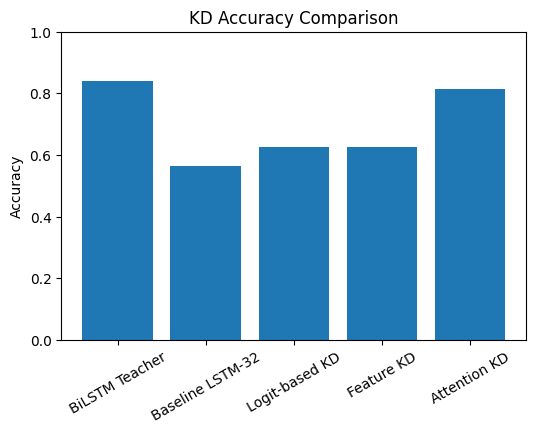

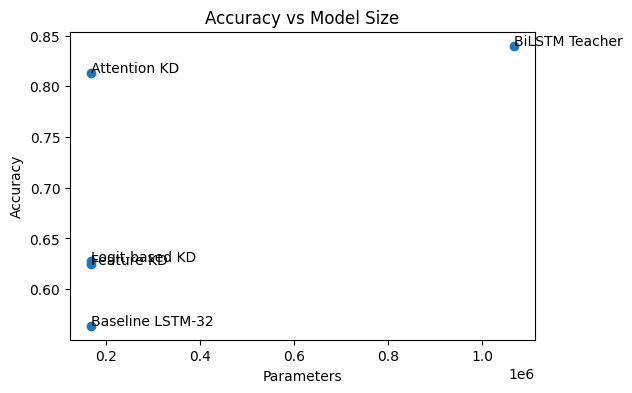

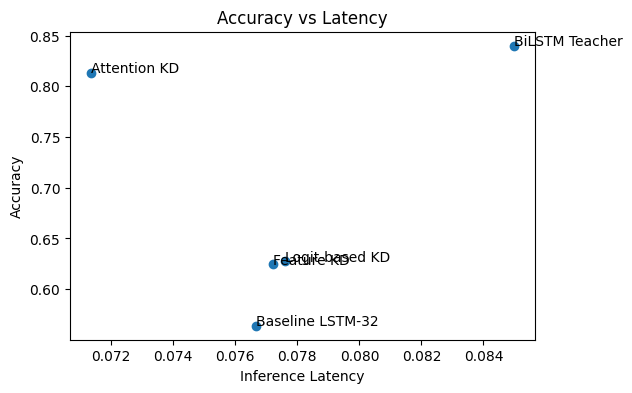

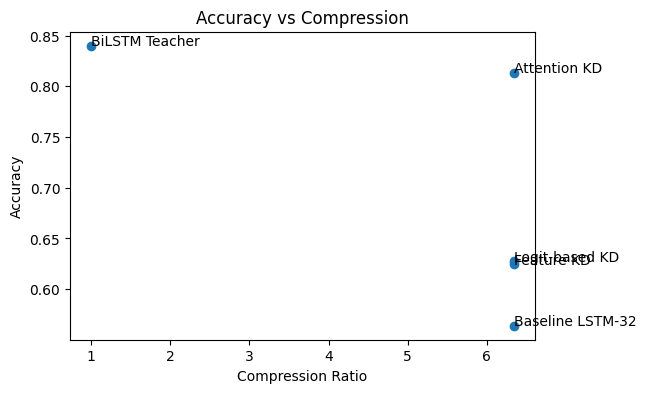

In [ ]:
all_accs = [r[1] for r in results]
all_params = [r[5] for r in results]
all_latencies = [r[7] for r in results]
all_compression = [r[8] for r in results]

plt.figure(figsize=(6,4))
plt.bar(all_names, all_accs)
plt.ylabel("Accuracy")
plt.title("KD Accuracy Comparison")
plt.xticks(rotation=30)
plt.ylim(0,1)
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(all_params, all_accs)
for i,label in enumerate(all_names):
    plt.annotate(label,(all_params[i],all_accs[i]))
plt.xlabel("Parameters")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Model Size")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(all_latencies, all_accs)
for i,label in enumerate(all_names):
    plt.annotate(label,(all_latencies[i],all_accs[i]))
plt.xlabel("Inference Latency")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Latency")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(all_compression, all_accs)
for i,label in enumerate(all_names):
    plt.annotate(label,(all_compression[i],all_accs[i]))
plt.xlabel("Compression Ratio")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Compression")
plt.show()


Sweeping temperature and alpha parameters for the top-performing KD models. Each combination was trained and evaluated, producing performance metrics for analysis.

In [ ]:
sorted_results = sorted(results[2:], key=lambda x: x[1], reverse=True)  # skip teacher and baseline
top2 = sorted_results[:2]
top2_names = [r[0] for r in top2]
top2_models = [student_kd if r[0] == "Logit-based KD" else student_feature if r[0] == "Feature KD" else student_attention for r in top2]

temperatures = [1, 2, 4, 8]
alphas = [0.3, 0.5, 0.7]
sweep_results = []

for model_name, base_model in zip(top2_names, top2_models):
    print(f"\nSweeping parameters for {model_name}...")
    for T in temperatures:
        for alpha in alphas:
            student = create_student_model()

            if model_name == "Logit-based KD":
                distiller = Distiller(student, temperature=T, alpha=alpha)
                train_data = train_dataset
                val_data = test_dataset
            elif model_name == "Feature KD":
                distiller = FeatureDistiller(student, teacher, alpha=alpha)
                train_data = tf.data.Dataset.from_tensor_slices((x_train_sub, y_train_sub)).shuffle(1000).batch(BATCH_SIZE)
                val_data = tf.data.Dataset.from_tensor_slices((x_test_sub, y_test_sub)).batch(BATCH_SIZE)
            elif model_name == "Attention KD":
                distiller = AttentionDistiller(student, teacher, temperature=T, alpha=alpha)
                train_data = train_dataset
                val_data = test_dataset

            distiller.compile(
                optimizer=tf.keras.optimizers.Adam(),
                metrics=[tf.keras.metrics.CategoricalAccuracy(name="accuracy")]
            )

            distiller.fit(train_data, validation_data=val_data, epochs=EPOCHS_STUDENT, verbose=0)

            acc, precision, recall, f1 = evaluate_metrics(student, x_test_sub, y_test_sub)
            sweep_results.append([model_name, T, alpha, acc, precision, recall, f1])

print(f"{'KD Model':15} {'T':3} {'Alpha':5} {'Acc':6} {'Prec':6} {'Rec':6} {'F1':6}")
for r in sweep_results:
    print(f"{r[0]:15} {r[1]:3} {r[2]:5.2f} {r[3]:.4f} {r[4]:.4f} {r[5]:.4f} {r[6]:.4f}")


Sweeping parameters for Attention KD...

Sweeping parameters for Logit-based KD...
KD Model        T   Alpha Acc    Prec   Rec    F1    
Attention KD      1  0.30 0.6570 0.7423 0.4292 0.5439
Attention KD      1  0.50 0.7865 0.7935 0.7461 0.7691
Attention KD      1  0.70 0.5880 0.6215 0.3463 0.4447
Attention KD      2  0.30 0.7950 0.7554 0.8426 0.7966
Attention KD      2  0.50 0.8095 0.8122 0.7807 0.7961
Attention KD      2  0.70 0.6125 0.5560 0.9265 0.6950
Attention KD      4  0.30 0.8155 0.8080 0.8038 0.8059
Attention KD      4  0.50 0.8020 0.7557 0.8636 0.8061
Attention KD      4  0.70 0.7000 0.7160 0.6139 0.6610
Attention KD      8  0.30 0.8270 0.7984 0.8520 0.8244
Attention KD      8  0.50 0.5845 0.5897 0.4208 0.4911
Attention KD      8  0.70 0.7995 0.7968 0.7775 0.7870
Logit-based KD    1  0.30 0.7810 0.8955 0.6118 0.7269
Logit-based KD    1  0.50 0.6910 0.6159 0.9339 0.7423
Logit-based KD    1  0.70 0.5790 0.5339 0.9182 0.6752
Logit-based KD    2  0.30 0.8125 0.7937 0.8195 0.806

Visualizing the effect of temperature and alpha on student model accuracy for the top KD models using heatmaps and line plots.

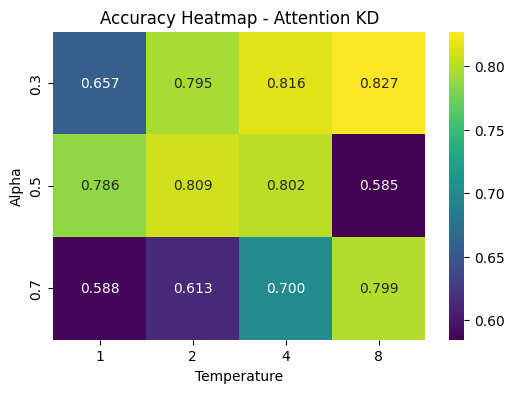

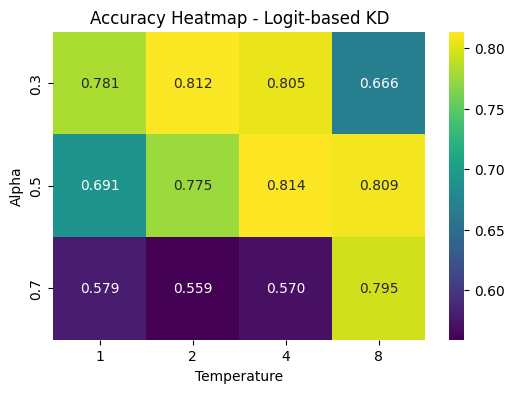

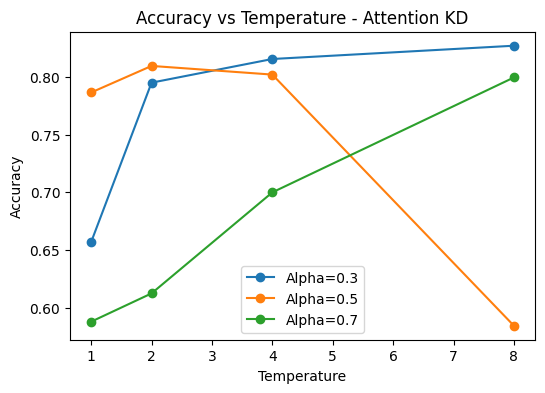

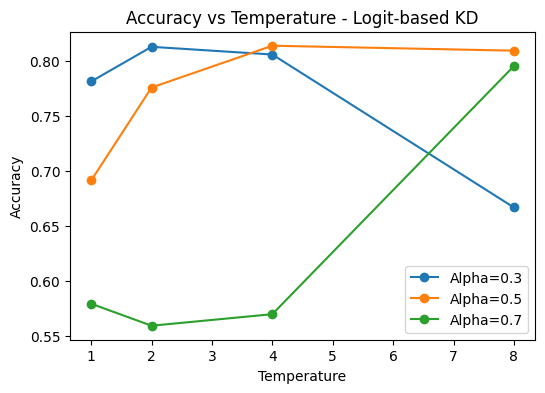

In [ ]:
df_sweep = pd.DataFrame(sweep_results, columns=["KD", "Temperature", "Alpha", "Acc", "Prec", "Rec", "F1"])

for model_name in top2_names:
    data = df_sweep[df_sweep["KD"] == model_name]
    pivot = data.pivot(index="Alpha", columns="Temperature", values="Acc")
    plt.figure(figsize=(6,4))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"Accuracy Heatmap - {model_name}")
    plt.ylabel("Alpha")
    plt.xlabel("Temperature")
    plt.show()

for model_name in top2_names:
    plt.figure(figsize=(6,4))
    data = df_sweep[df_sweep["KD"] == model_name]
    for alpha in sorted(data["Alpha"].unique()):
        subset = data[data["Alpha"] == alpha]
        plt.plot(subset["Temperature"], subset["Acc"], marker='o', label=f"Alpha={alpha}")
    plt.title(f"Accuracy vs Temperature - {model_name}")
    plt.xlabel("Temperature")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()
